<a href="https://colab.research.google.com/github/nekuroomancy/exemplos-CN/blob/main/NewtonDiscreto_MMQ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>





# Unidade 5 - Aproximação de funções




Nesta unidade, vamos estudar métodos para aproximar funções e dados tabelados. Veremos duas maneiras de aproximar funções: a **Interpolação** e o **Método dos Mínimos Quadrados**. A seguir, apresentamos alguns exemplos de resolução em *Python*. Vamos utilizar as bibliotecas [numpy](https://numpy.org/) e [scipy](https://scipy.github.io/devdocs/index.html).

**Motivação:**

Podemos estar interessados em extrair informações de um conjunto de dados de censos demográficos, que em geral ocorre a cada 10 anos. Como estimar a população em anos intermediários?

Podemos também aproximar funções $f(x)$ contínuas por uma combinação de polinômios ou funções trigonométricas, por exemplo.

Existem duas classes de métodos:


*   Método dos Mínimos Quadrados (MMQ): nosso objetivo é minimizar o resíduo entre os dados e uma função aproximadora.
*   Interpolação Polinomial: nesse caso exigimos que o polinômio aproximador "passe" pelos dados a serem aproximados.



# Método dos Mínimos Quadrados


**Problema Discreto:**

Objetivo: Minimizar resíduo (erro).

Para obter a melhor aproximação vamos minimizar a função:

$$  r({\bf a}) = \sum_{i=1}^m r_i({\bf a})^2,$$

sendo o resíduo $r_i({\bf a}) = f(x_i,{\bf a}) - y_i$, com $(x_i,y_i)$ dados e $m$ tamanho dos vetores $x$ e $y$.

Para ajustar os parâmetros da função $r({\bf a})$ vamos fazer algumas implementações simples e utilizar as bibliotecas *numpy* e *scipy*.

Para a **Regressão Linear**, cuja função aproximadora é $g(x) = a_0+a_1x$, já deduzimos o sistema linear normal,

 $$\left(\begin{array}{cc}
    \sum_{i=1}^m1 & \sum_{i=1}^mx_i\\
    \sum_{i=1}^mx_i & \sum_{i=1}^mx_i^2\\
  \end{array}\right)\left(\begin{array}{c}
  a_0\\
  a_1\\
  \end{array}\right)= \left(\begin{array}{c}
  \sum_{i=1}^my_i,\\
  \sum_{i=1}^mx_iy_i
  \end{array}\right),$$
onde obtemos os parâmetros $a_0$ e $a_1$ que minimizam a função resíduo.

Note que podemos simplificar a notação:

$< {\bf 1},{\bf 1} > = \sum_{i=1}^m 1$

$< {\bf 1}, {\bf x}> = \sum_{i=1}^mx_i$

$< {\bf x}, {\bf x} > = \sum_{i=1}^mx_i^2$

$< {\bf y}, {\bf x} > = \sum_{i=1}^my_ix_i$



 *Assunto descrito em aula, para mais detalhes, veja material disponível no moodle.*

**Exemplo 1**

Ajustar os dados abaixo usando uma reta (Regressão linear):

$$\begin{array}{c|ccccc}
x_i & 0 & 0.25 & 0.5 & 0.75 & 1\\
\hline
y_i & 1 & 1.2840 & 1.6487 & 2.1170 & 2.7183 \\
\end{array}$$

*Solução:*

A função aproximadora é dada por $g(x)=a_0 + a_1x$.

0.039198364000000055
[0.89968 1.70784]


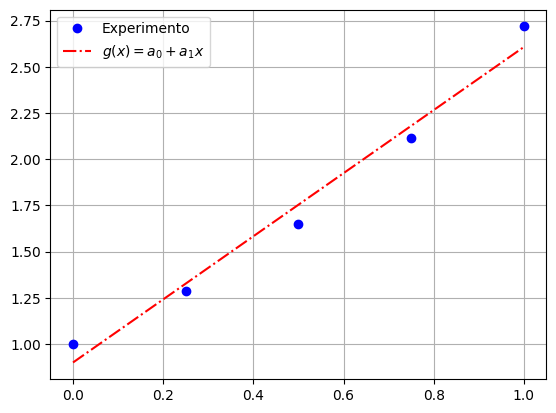

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def g(x,a):
  return a[0] + a[1]*x

def r(a,x,y):
  soma = 0
  n = len(x)
  for i in range(n):
    soma += (y[i] - g(x[i],a))**2
  return soma

x = np.array([0, 0.25, 0.5, 0.75, 1])
y = np.array([1, 1.284, 1.6487, 2.1170, 2.7183])

n = 2
N = np.zeros((n,n))
b = np.zeros(n)
m = len(x)
u = np.ones(m)
# usamos produto escalar pra fazer o somatório (e integrais no contínuo)
N[0][0] = np.dot(u,u)
N[0][1] = np.dot(u,x)
N[1][0] = N[0][1]
N[1][1] = np.dot(x,x)

b[0] = np.dot(u,y)
b[1] = np.dot(x,y)

a = np.linalg.solve(N,b)
res = r(a,x,y)
print(res)
print(a)

plt.figure(1)
plt.plot(x,y,'bo',label='Experimento')
plt.plot(x,g(x,a),'r-.', label='$g(x)=a_0+a_1x$')
plt.legend()
plt.grid()
plt.show()

Para uma função aproximadora da forma $g(x) = a_0+a_1x+a_2x^2$, de forma similar a dedução feita para a **Regressão Linear**, obtemos o sistema linear normal,

 $$\left(\begin{array}{ccc}
    <{\bf 1}, {\bf 1}> & <{\bf x},{\bf 1}> & <{\bf x}²,{\bf 1}>\\
    <{\bf 1}, {\bf x}> & <{\bf x},{\bf x}> & <{\bf x}², {\bf x}>\\
    <{\bf 1},{\bf x}^2> & <{\bf x}, {\bf x}²> & <{\bf x}²,{\bf x}²>
  \end{array}\right)\left(\begin{array}{c}
  a_0\\
  a_1\\
  a_2 \\
  \end{array}\right)= \left(\begin{array}{c}
  <{\bf y},{\bf 1}>\\
  <{\bf y},{\bf x}>\\
  <{\bf y},{\bf x}²>
  \end{array}\right),$$
onde obtemos os parâmetros $a_0$, $a_1$ e $a_2$ que minimizam a função resíduo.


**Exemplo 2:**

Repita o exercício anterior ajustando os dados com uma função quadrática: $g(x)=a_0+a_1x+a_2x^2$.

0.0002741325714285763
[1.00513714 0.86418286 0.84365714]


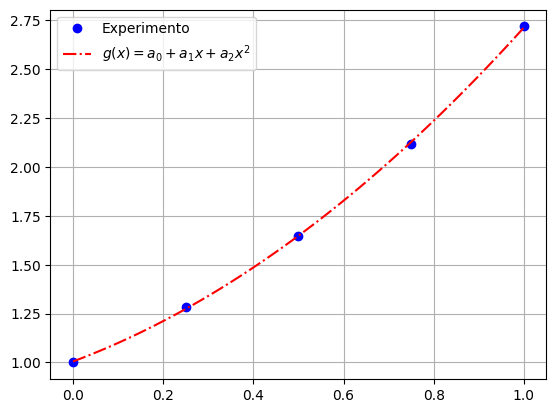

In [10]:
#g[0] = 1
#g[1] = x
#g[2] = x**2

import numpy as np
import matplotlib.pyplot as plt

def g(x,a):
  return a[0] + a[1]*x + a[2]*x**2

def r(a,x,y):
  soma = 0
  n = len(x)
  for i in range(n):
    soma += (y[i] - g(x[i],a))**2
  return soma

x = np.array([0, 0.25, 0.5, 0.75, 1])
y = np.array([1, 1.284, 1.6487, 2.1170, 2.7183])

n = 3
N = np.zeros((n,n))
b = np.zeros(n)
m = len(x)
u = np.ones(m)
x2 = np.zeros(m)
# usamos produto escalar pra fazer o somatório (e integrais no contínuo)
for i in range(m):
  x2[i] = x[i]**2

N[0][0] = np.dot(u,u)
N[0][1] = np.dot(u,x)
N[0][2] = np.dot(u,x2)
N[1][0] = N[0][1]
N[1][1] = np.dot(x,x)
N[1][2] = np.dot(x2,x)
N[2][0] = N[0][2]
N[2][1] = N[1][2]
N[2][2] = np.dot(x2,x2)

b[0] = np.dot(u,y)
b[1] = np.dot(x,y)
b[2] = np.dot(x2,y)

a = np.linalg.solve(N,b)
res = r(a,x,y)
print(res)
print(a)

xx = np.linspace(x[0],x[m-1],50) #deixa a curva mais "suave"
plt.figure(1)
plt.plot(x,y,'bo',label='Experimento')
plt.plot(xx,g(xx,a),'r-.', label='$g(x)=a_0+a_1x+a_2x^2$')
plt.legend()
plt.grid()
plt.show()

**Exemplo 3:**

Dada a tabela de valores
$$\begin{array}{c|ccccccc}
x & 1 & 2 & 3 & 4 & 5 & 6 & 7 & 8\\
\hline
f(x) & 0.5 & 0.6 & 0.9 & 0.8 & 1.2 & 1.5 & 1.7 & 2\\
\end{array}$$

(a) Obtenha a melhor reta que aproxima os dados via MMQ.

(b) Obtenha a melhor função quadrática que aproxima os dados via MMQ.


Para uma função aproximadora da forma $g(x) = a_0g_0(x)+a_1g_1(x)+\ldots+a_ng_n(x)$, generalizando a dedução feita anteriormente, obtemos o sistema linear normal,

 $$\left(\begin{array}{ccccc}
    <{\bf g}_0, {\bf g}_0> & <{\bf g}_1,{\bf g}_0> & \ldots & <{\bf g}_n,{\bf g}_0>\\
    <{\bf g}_0, {\bf g}_1> & <{\bf g}_1,{\bf g}_1> & \ldots & <{\bf g}_n, {\bf g}_1>\\
     \vdots & & \ddots & \vdots \\
    <{\bf g}_0,{\bf g}_n> & <{\bf g}_1, {\bf g}_n> & \ldots & <{\bf g}_n,{\bf g}_n>
  \end{array}\right)\left(\begin{array}{c}
  a_0\\
  a_1\\
  \vdots \\
  a_n\\
  \end{array}\right)= \left(\begin{array}{c}
  <{\bf y},{\bf g}_0>\\
  <{\bf y},{\bf g}_1>\\
  \vdots \\
  <{\bf y},{\bf g}_n>
  \end{array}\right),$$
onde obtemos os parâmetros $a_0$, $a_1$, \ldots e $a_n$ que minimizam a função resíduo.

**Exemplo 4:**

Observando o sinal de um osciloscópio verifica-se que ele corresponde a superposição de dois efeitos, um oscilatório e outro crescente.
Aproxime os dados da tabela usando $g(x)=a_0x +a_1\cos(x)$  como função aproximadora.

$$\begin{array}{c|cccccccc}
x_i & 0 & 1.5 & 3 & 4.5 &6\\
\hline
f(x_i) & 1 & 1.57 & 2 & 4.3 & 7 \\
\end{array}
$$

0.0003196239999689366
[1.0034159  1.01327032]


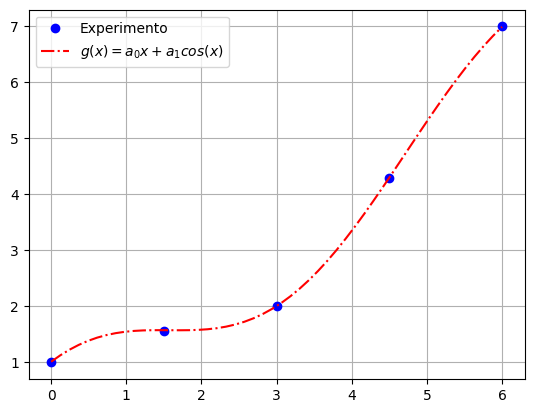

In [15]:
# g[0] = x
# g[1] = cos(x)
# N = [<x,x>      <x,cosx] ]   b = [ <x,y>  ]
#     [<cosx,x>  <cosx,cosx]       [<cosx,y>]

import numpy as np
import matplotlib.pyplot as plt

def g(x,a):
  return a[0]*x + a[1]*np.cos(x)

def r(a,x,y):
  soma = 0
  n = len(x)
  for i in range(n):
    soma += (y[i] - g(x[i],a))**2
  return soma

x = np.array([0, 1.5, 3, 4.5, 6])
y = np.array([1, 1.57, 2, 4.3, 7])

n = 2
N = np.zeros((n,n))
b = np.zeros(n)
m = len(x)
cs = np.cos(x)

# usamos produto escalar pra fazer o somatório (e integrais no contínuo)
N[0][0] = np.dot(x,x)
N[0][1] = np.dot(x,cs)
N[1][0] = N[0][1]
N[1][1] = np.dot(cs,cs)

b[0] = np.dot(x,y)
b[1] = np.dot(cs,y)

a = np.linalg.solve(N,b)
res = r(a,x,y)
print(res)
print(a)

xx = np.linspace(x[0],x[m-1],50)
plt.figure(1)
plt.plot(x,y,'bo',label='Experimento')
plt.plot(xx,g(xx,a),'r-.', label='$g(x)=a_0x+a_1cos(x)$')
plt.legend()
plt.grid()
plt.show()


**Exemplo 5:**

O número de bactérias por unidade de volume, existente em uma cultura após $x$ horas é apresentado na tabela:

$$\begin{array}{c|ccccc}
x_i & 0.5 & 1 & 2 & 3 & 4 & 5 & 6\\
\hline
y_i & 32 & 47 & 65 & 92 & 132 & 190 & 275 \\
\end{array}$$

(a) Faça um gráfico da tabela para auxiliar na escolha da função aproximadora.

(b) Faça uma linearização, para transformar as funções aproximadoras $g(x) = ab^x$ e $h(x)=ax^b$ na forma $G(x) = B + Ax$.

(c) Ajuste os dados com uma aproximação linear e com as funções aproximadoras do item (b). Analise os resultados comparando com os dados.

**Finalizando Sistemas não lineares:**

**Método de Newton**

É dado por

$${\bf x}^{(k+1)} = {\bf x}^{(k)} - [J({\bf x})^{(k)}]^{-1}{\bf F}({\bf x}^{(k)})$$

Como o cálculo da matriz inversa pode ser proibitivo, na prática resolvemos o sistema um sistema linear a cada iteração do método. Assim, a cada iteração do método precisamos:    

(a) Avaliar $J({\bf x})$ e ${\bf F}({\bf x})$.

(b) Resolver um sistema linear: $J({\bf x}){\bf s} = -{\bf F}({\bf x}).$

(c) Atualizar a solução: ${\bf x}^{(k+1)}={\bf x}^{(k)} + {\bf s}$

**Exemplo 1:**

Utilize o método de Newton para resolver o sistema não linear, partindo da aproximação inicial ${\bf x}^{(0)}=(1.2,1.7)$.
 $$\left\{\begin{array}{lll}
  2x_1^3-x_2^2 & = & 1\\
  x_1x_2^3-x_2 & = & 4
  \end{array}\right .$$

Primeiro, vamos escrever o sistema no formato ${\bf F}({\bf x})={\bf 0}$. Neste caso, temos $f_1(x_1,x_2)= 2x_1^3-x_2^2  - 1$ e $f_2(x_1,x_2)=x_1x_2^3-x_2 - 4$, com ${\bf x}=(x_1,x_2)$ e então,

$${\bf F}({\bf x}) = \left ( \begin{array}{c}
  2x_1^3-x_2^2  - 1\\
  x_1x_2^3-x_2 - 4\\
  \end{array}\right )$$

Vamos determinar a matriz Jacobiana,

$$J({\bf x})=\left ( \begin{array}{cc}
  \frac{\partial f_1}{\partial x_1} & \frac{\partial f_1}{\partial x_2}\\
 \frac{\partial f_2}{\partial x_1} & \frac{\partial f_2}{\partial x_2}\\
  \end{array}\right ) = \left ( \begin{array}{cc}
  6x_1^2 & -2x_2\\
 x_2^3 & 3x_1x_2^2 - 1\\
  \end{array}\right )$$

Agora vamos fazer uma iteração do método de Newton, usando 6 algarismos significativos.

A cada iteração precisamos realizar os passos (a), (b) e (c) descritos acima.

*Iteração 1:*

(a) Avaliar ${\bf F}({\bf x}^{(0)})$ e $J({\bf x}^{(0)})$, com ${\bf x}^{(0)}=(1.2,1.7)$. Temos,

$${\bf F}({\bf x}^{(0)}) = \left ( \begin{array}{c}
  2x_1^3-x_2^2  - 1\\
  x_1x_2^3-x_2 - 4\\
  \end{array}\right ) = \left ( \begin{array}{c}
  2\times 1.2^3-1.7^2  - 1\\
  1.2\times 1.7^3-1.7 - 4\\
  \end{array}\right ) = \left ( \begin{array}{c}
  -0.434\\
  0.1956\\
  \end{array}\right ) \ \mbox{ e }$$

  $$J({\bf x}^{(0)})= \left ( \begin{array}{cc}
  6x_1^2 & -2x_2\\
 x_2^3 & 3x_1x_2^2 - 1\\
  \end{array}\right ) = \left ( \begin{array}{cc}
  6\times 1.2^2 & -2\times 1.7\\
 1.7^3 & 3\times 1.2\times 1.7^2 - 1\\
  \end{array}\right ) = \left ( \begin{array}{cc}
  8.64 & -3.4\\
 4.913 & 9.404\\
  \end{array}\right )$$

(b) Resolver o sistema $J({\bf x}^{(0)}){\bf s}=-{\bf F}({\bf x}^{(0)})$. Neste caso,

$$\left ( \begin{array}{cc}
  8.64 & -3.4\\
 4.913 & 9.404\\
  \end{array}\right )\left (\begin{array}{c}
  s_1\\
  s_2\\
  \end{array}\right) = \left ( \begin{array}{c}
  0.434\\
  -0.1956\\
  \end{array}\right )$$

  Usando o método de Eliminação de Gauss,

  $$\left ( \begin{array}{cc|c}
  8.64 & -3.4 & 0.434 \\
 4.913 & 9.404 & -0.1956 \\
  \end{array}\right )\sim \left ( \begin{array}{cc|c}
  8.64 & -3.4 & 0.434 \\
 0.568634 & 11.3374 & -0.442387 \\
  \end{array}\right )$$

Com um passo do método de Eliminação de Gauss: $L_2 \leftarrow L_2 - m_{21}L_1$, com $m_{21}=\frac{4.913}{8.64}\approx 0.568634$ (armazenada na posição $a_{21}$ da matriz aumentada) e os demais elementos da segunda linha da matriz aumentada: $a_{22}=9.404 - 0.568634\times (-3.4) \approx 11.3374$ e $b_2= -0.1956-0.568634\times 0.434\approx -0.442387.$ Resolvendo o sistema triangular superior:

$$s_2 = \frac{-0.442387}{11.3374}\approx -0.0390201,$$

$$s_1 = \frac{0.434 + 3.4\times (-0.0390201)}{8.64} \approx \frac{0.301332}{8.64} \approx 0.0348764.$$

(c) Atualizar a solução: ${\bf x}^{(k+1)} = {\bf x}^{(k)} + {\bf s}$.

Dessa forma, ${\bf x}^{(1)} = {\bf x}^{(0)} + {\bf s}.$ Portanto,

$$x_1^{(1)} = x_1^{(0)} + s_1 = 1.2 + 0.0348764 \approx 1.23488$$

$$x_2^{(1)} = x_2^{(0)} + s_2 = 1.7 - 0.0390201 \approx 1.66098$$

Ao avaliar, ${\bf F}({\bf x}^{(1)})$ temos uma medida de quão próximo da solução estamos,

$${\bf F}({\bf x}^{(1)}) = \left (\begin{array}{c}
  2x_1^3-x_2^2  - 1\\
  x_1x_2^3-x_2 - 4\\
  \end{array}\right ) = \left (\begin{array}{c}
  2\times 1.23488^3-1.66098^2  - 1\\
  1.23488\times 1.66098^3-1.66098 - 4\\
  \end{array}\right ) = \left (\begin{array}{c}
  0.00735313\\
  -0.00226311\\
  \end{array}\right )$$

  Agora faça a segunda iteração deste problema como exercício.

  Em seguida, vamos implementar o método de Newton para este problema.






 **Método de Newton Discreto:**

 A ideia é aproximar as derivadas parciais numericamente usando o Método de Diferenças Finitas. O Método de Diferenças Finitas são aproximações para as derivadas com base na série de Taylor.

 $$\frac{\partial f_i}{\partial x_j}\approx \frac{f_i(x_1,\ldots,x_j+h,\ldots,x_n)-f_i(x_1,\ldots,x_j,\ldots,x_n)}{h}$$    

 **Exemplo 2:**

Utilize o método de Newton Discreto (com h = 0.1 ou h=0.01) para resolver o sistema não linear, partindo da aproximação inicial ${\bf x}^{(0)}=(1.2,1.7)$.
 $$\left\{\begin{array}{lll}
  2x_1^3-x_2^2 & = & 1\\
  x_1x_2^3-x_2 & = & 4
  \end{array}\right .$$
